In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# ****Load and clean all 19 columns — parse dates, handle nulls, encode all categorical variables****

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_csv('global_hantavirus_surveillance_dataset_2026.csv', index_col=0)

In [4]:
df.head(10)

,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
case_id,,,,,,,,,,,,,,,,,,
HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132
HV2026_00006,Peru,Port Cheryl,17-12-2025,Puumala,Human-to-Human,Rodent Exposure,53,Male,"Headache, Vomiting, Fever",Yes,No,9.0,28.6,93.2,6,6,8229,222
HV2026_00007,Uruguay,Bowenberg,29-03-2026,Dobrava,Human-to-Human,Agricultural Exposure,70,Female,"Headache, Vomiting, Fever",Yes,No,22.0,21.2,45.9,7,11,3643,90
HV2026_00008,USA,Payneport,18-09-2025,Sin Nombre,Human-to-Human,Home Infestation,75,Male,"Fatigue, Nausea, Chills",Yes,No,14.0,27.3,46.0,7,19,7718,290
HV2026_00009,Brazil,South Kimberly,09-05-2025,Seoul,Rodent-to-Human,Forest Exposure,13,Female,"Fever, Cough, Headache",Yes,No,41.0,25.5,60.9,8,0,4365,276


In [5]:
df.isnull().sum()

country                    0
region                     0
report_date                0
virus_strain               0
transmission_type          0
exposure_source            0
patient_age                0
gender                     0
symptoms                   0
hospitalization            0
fatality                   0
recovery_days            155
temperature_celsius        0
humidity_percent           0
rodent_presence_index      0
quarantine_days            0
population_density         0
air_quality_index          0
dtype: int64

In [6]:
df['country'].value_counts()

country
Bolivia      215
Argentina    211
Canada       208
USA          208
Brazil       207
Uruguay      202
Mexico       196
Paraguay     193
Chile        190
Peru         170
Name: count, dtype: int64

In [7]:
df = pd.get_dummies(df, columns=['country'], dtype=int)

In [8]:
df.head(10)

,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index,country_Argentina,country_Bolivia,country_Brazil,country_Canada,country_Chile,country_Mexico,country_Paraguay,country_Peru,country_USA,country_Uruguay
case_id,,,,,,,,,,,,,,,,,,,,,,,,,,,
HV2026_00001,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67,0,0,0,1,0,0,0,0,0,0
HV2026_00002,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162,0,1,0,0,0,0,0,0,0,0
HV2026_00003,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213,0,0,0,0,1,0,0,0,0,0
HV2026_00004,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206,1,0,0,0,0,0,0,0,0,0
HV2026_00005,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132,0,0,0,0,1,0,0,0,0,0
HV2026_00006,Port Cheryl,17-12-2025,Puumala,Human-to-Human,Rodent Exposure,53,Male,"Headache, Vomiting, Fever",Yes,No,9.0,28.6,93.2,6,6,8229,222,0,0,0,0,0,0,0,1,0,0
HV2026_00007,Bowenberg,29-03-2026,Dobrava,Human-to-Human,Agricultural Exposure,70,Female,"Headache, Vomiting, Fever",Yes,No,22.0,21.2,45.9,7,11,3643,90,0,0,0,0,0,0,0,0,0,1
HV2026_00008,Payneport,18-09-2025,Sin Nombre,Human-to-Human,Home Infestation,75,Male,"Fatigue, Nausea, Chills",Yes,No,14.0,27.3,46.0,7,19,7718,290,0,0,0,0,0,0,0,0,1,0
HV2026_00009,South Kimberly,09-05-2025,Seoul,Rodent-to-Human,Forest Exposure,13,Female,"Fever, Cough, Headache",Yes,No,41.0,25.5,60.9,8,0,4365,276,0,0,1,0,0,0,0,0,0,0


In [9]:
df['region'].value_counts()

region
New Matthew                 4
South James                 4
West Jennifer               4
West Michael                4
South Tamara                3
Port Christopher            3
South Karen                 3
East John                   3
North Justin                3
Lake Daniel                 3
Port Ryan                   3
West Amanda                 3
Hallville                   3
New Rachel                  3
Aarontown                   3
North Amy                   3
Joneston                    3
South Christopher           3
North Michael               3
Michaelmouth                3
West Kimberly               3
North Elizabeth             3
Port James                  3
Lake Timothy                3
East Charles                3
New William                 3
Brownside                   2
Collinsport                 2
Josephside                  2
North Robert                2
Melissaview                 2
Michaelhaven                2
North John                  2
Wes

In [10]:
df['region'] = df['region'].map(df['region'].value_counts())

In [11]:
df['region'].value_counts()

region
1    1730
2     188
3      66
4      16
Name: count, dtype: int64

In [12]:
df['report_date'] = pd.to_datetime(df['report_date'], format='%d-%m-%Y')
df['report_date_year'] = df['report_date'].dt.year
df['report_date_month'] = df['report_date'].dt.month
df['report_date_day'] = df['report_date'].dt.day
df = df.drop('report_date', axis=1)

In [13]:
df.head(10)

,region,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index,country_Argentina,country_Bolivia,country_Brazil,country_Canada,country_Chile,country_Mexico,country_Paraguay,country_Peru,country_USA,country_Uruguay,report_date_year,report_date_month,report_date_day
case_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
HV2026_00001,1,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67,0,0,0,1,0,0,0,0,0,0,2025,11,24
HV2026_00002,1,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162,0,1,0,0,0,0,0,0,0,0,2025,4,22
HV2026_00003,1,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213,0,0,0,0,1,0,0,0,0,0,2025,3,21
HV2026_00004,1,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206,1,0,0,0,0,0,0,0,0,0,2025,2,10
HV2026_00005,1,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132,0,0,0,0,1,0,0,0,0,0,2025,3,25
HV2026_00006,1,Puumala,Human-to-Human,Rodent Exposure,53,Male,"Headache, Vomiting, Fever",Yes,No,9.0,28.6,93.2,6,6,8229,222,0,0,0,0,0,0,0,1,0,0,2025,12,17
HV2026_00007,1,Dobrava,Human-to-Human,Agricultural Exposure,70,Female,"Headache, Vomiting, Fever",Yes,No,22.0,21.2,45.9,7,11,3643,90,0,0,0,0,0,0,0,0,0,1,2026,3,29
HV2026_00008,1,Sin Nombre,Human-to-Human,Home Infestation,75,Male,"Fatigue, Nausea, Chills",Yes,No,14.0,27.3,46.0,7,19,7718,290,0,0,0,0,0,0,0,0,1,0,2025,9,18
HV2026_00009,1,Seoul,Rodent-to-Human,Forest Exposure,13,Female,"Fever, Cough, Headache",Yes,No,41.0,25.5,60.9,8,0,4365,276,0,0,1,0,0,0,0,0,0,0,2025,5,9


In [14]:
df['virus_strain'].value_counts()

virus_strain
Sin Nombre    431
Seoul         414
Andes         394
Dobrava       387
Puumala       374
Name: count, dtype: int64

In [15]:
df = pd.get_dummies(df, columns=['virus_strain'], dtype=int)

In [16]:
df.head(10)

,region,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index,country_Argentina,country_Bolivia,country_Brazil,country_Canada,country_Chile,country_Mexico,country_Paraguay,country_Peru,country_USA,country_Uruguay,report_date_year,report_date_month,report_date_day,virus_strain_Andes,virus_strain_Dobrava,virus_strain_Puumala,virus_strain_Seoul,virus_strain_Sin Nombre
case_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
HV2026_00001,1,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67,0,0,0,1,0,0,0,0,0,0,2025,11,24,0,0,0,0,1
HV2026_00002,1,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162,0,1,0,0,0,0,0,0,0,0,2025,4,22,0,0,0,0,1
HV2026_00003,1,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213,0,0,0,0,1,0,0,0,0,0,2025,3,21,0,0,0,1,0
HV2026_00004,1,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206,1,0,0,0,0,0,0,0,0,0,2025,2,10,0,0,0,0,1
HV2026_00005,1,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132,0,0,0,0,1,0,0,0,0,0,2025,3,25,0,1,0,0,0
HV2026_00006,1,Human-to-Human,Rodent Exposure,53,Male,"Headache, Vomiting, Fever",Yes,No,9.0,28.6,93.2,6,6,8229,222,0,0,0,0,0,0,0,1,0,0,2025,12,17,0,0,1,0,0
HV2026_00007,1,Human-to-Human,Agricultural Exposure,70,Female,"Headache, Vomiting, Fever",Yes,No,22.0,21.2,45.9,7,11,3643,90,0,0,0,0,0,0,0,0,0,1,2026,3,29,0,1,0,0,0
HV2026_00008,1,Human-to-Human,Home Infestation,75,Male,"Fatigue, Nausea, Chills",Yes,No,14.0,27.3,46.0,7,19,7718,290,0,0,0,0,0,0,0,0,1,0,2025,9,18,0,0,0,0,1
HV2026_00009,1,Rodent-to-Human,Forest Exposure,13,Female,"Fever, Cough, Headache",Yes,No,41.0,25.5,60.9,8,0,4365,276,0,0,1,0,0,0,0,0,0,0,2025,5,9,0,0,0,1,0


In [17]:
df['transmission_type'].value_counts()

transmission_type
Human-to-Human     1001
Rodent-to-Human     999
Name: count, dtype: int64

In [18]:
le_transmission_type = LabelEncoder() 
df['transmission_type'] = le_transmission_type.fit_transform(df['transmission_type'])

In [19]:
df['transmission_type'].value_counts()

transmission_type
0    1001
1     999
Name: count, dtype: int64

In [20]:
df['exposure_source'].value_counts()

exposure_source
Cruise Exposure          354
Warehouse Exposure       346
Rodent Exposure          336
Home Infestation         331
Forest Exposure          325
Agricultural Exposure    308
Name: count, dtype: int64

In [21]:
df = pd.get_dummies(df, columns=['exposure_source'], dtype=int)

In [22]:
df.head(10)

,region,transmission_type,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index,country_Argentina,country_Bolivia,country_Brazil,country_Canada,country_Chile,country_Mexico,country_Paraguay,country_Peru,country_USA,country_Uruguay,report_date_year,report_date_month,report_date_day,virus_strain_Andes,virus_strain_Dobrava,virus_strain_Puumala,virus_strain_Seoul,virus_strain_Sin Nombre,exposure_source_Agricultural Exposure,exposure_source_Cruise Exposure,exposure_source_Forest Exposure,exposure_source_Home Infestation,exposure_source_Rodent Exposure,exposure_source_Warehouse Exposure
case_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
HV2026_00001,1,1,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67,0,0,0,1,0,0,0,0,0,0,2025,11,24,0,0,0,0,1,1,0,0,0,0,0
HV2026_00002,1,0,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162,0,1,0,0,0,0,0,0,0,0,2025,4,22,0,0,0,0,1,0,0,0,1,0,0
HV2026_00003,1,0,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213,0,0,0,0,1,0,0,0,0,0,2025,3,21,0,0,0,1,0,0,0,0,1,0,0
HV2026_00004,1,0,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206,1,0,0,0,0,0,0,0,0,0,2025,2,10,0,0,0,0,1,0,0,0,0,1,0
HV2026_00005,1,1,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132,0,0,0,0,1,0,0,0,0,0,2025,3,25,0,1,0,0,0,0,0,0,1,0,0
HV2026_00006,1,0,53,Male,"Headache, Vomiting, Fever",Yes,No,9.0,28.6,93.2,6,6,8229,222,0,0,0,0,0,0,0,1,0,0,2025,12,17,0,0,1,0,0,0,0,0,0,1,0
HV2026_00007,1,0,70,Female,"Headache, Vomiting, Fever",Yes,No,22.0,21.2,45.9,7,11,3643,90,0,0,0,0,0,0,0,0,0,1,2026,3,29,0,1,0,0,0,1,0,0,0,0,0
HV2026_00008,1,0,75,Male,"Fatigue, Nausea, Chills",Yes,No,14.0,27.3,46.0,7,19,7718,290,0,0,0,0,0,0,0,0,1,0,2025,9,18,0,0,0,0,1,0,0,0,1,0,0
HV2026_00009,1,1,13,Female,"Fever, Cough, Headache",Yes,No,41.0,25.5,60.9,8,0,4365,276,0,0,1,0,0,0,0,0,0,0,2025,5,9,0,0,0,1,0,0,0,1,0,0,0


In [23]:
df['patient_age'].unique()

array([26, 41, 39, 49, 59, 53, 70, 75, 13, 34, 14, 72, 43, 16, 64, 36, 45,
       18, 50, 31, 12, 47, 67, 37, 68, 30, 71, 61, 66, 65, 32, 46, 42, 56,
       35, 28, 73, 19, 69, 40, 52, 22, 23, 17, 58, 62, 29, 20, 15, 48, 55,
       51, 25, 21, 24, 27, 77, 76, 54, 57, 38, 63, 44, 78, 74, 33, 60])

In [24]:
df['gender'].value_counts()

gender
Male      1005
Female     995
Name: count, dtype: int64

In [25]:
le_gender = LabelEncoder()
df['gender'] = le_gender.fit_transform(df['gender'])

In [26]:
df['gender'].value_counts()

gender
1    1005
0     995
Name: count, dtype: int64

In [27]:
df['symptoms'].value_counts()

symptoms
Fever, Muscle Pain, Fatigue    405
Fever, Cough, Headache         404
Shortness of Breath, Fever     402
Fatigue, Nausea, Chills        395
Headache, Vomiting, Fever      394
Name: count, dtype: int64

In [28]:
df = pd.get_dummies(df, columns=['symptoms'], dtype=int)

In [29]:
df['hospitalization'].value_counts()

hospitalization
Yes    1007
No      993
Name: count, dtype: int64

In [30]:
le_hospitalization = LabelEncoder()
df['hospitalization'] = le_hospitalization.fit_transform(df['hospitalization'])

In [31]:
df['hospitalization'].value_counts()

hospitalization
1    1007
0     993
Name: count, dtype: int64

In [32]:
df['fatality'].value_counts()

fatality
No     1845
Yes     155
Name: count, dtype: int64

In [33]:
le_fatality = LabelEncoder()
df['fatality'] = le_fatality.fit_transform(df['fatality'])

In [34]:
df['fatality'].value_counts()

fatality
0    1845
1     155
Name: count, dtype: int64

In [35]:
df['recovery_days'].value_counts(dropna=False)

recovery_days
NaN     155
31.0     79
12.0     65
32.0     62
42.0     61
18.0     55
14.0     54
44.0     53
35.0     51
24.0     51
45.0     51
23.0     50
41.0     50
16.0     50
27.0     48
34.0     47
37.0     47
9.0      46
22.0     46
11.0     46
20.0     46
39.0     46
25.0     46
8.0      45
43.0     44
15.0     44
36.0     44
7.0      43
33.0     43
28.0     43
29.0     43
13.0     41
21.0     41
30.0     40
38.0     39
40.0     39
26.0     38
10.0     38
17.0     38
19.0     32
Name: count, dtype: int64

In [36]:
df[df['recovery_days'].isna()]

,region,transmission_type,patient_age,gender,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index,country_Argentina,country_Bolivia,country_Brazil,country_Canada,country_Chile,country_Mexico,country_Paraguay,country_Peru,country_USA,country_Uruguay,report_date_year,report_date_month,report_date_day,virus_strain_Andes,virus_strain_Dobrava,virus_strain_Puumala,virus_strain_Seoul,virus_strain_Sin Nombre,exposure_source_Agricultural Exposure,exposure_source_Cruise Exposure,exposure_source_Forest Exposure,exposure_source_Home Infestation,exposure_source_Rodent Exposure,exposure_source_Warehouse Exposure,"symptoms_Fatigue, Nausea, Chills","symptoms_Fever, Cough, Headache","symptoms_Fever, Muscle Pain, Fatigue","symptoms_Headache, Vomiting, Fever","symptoms_Shortness of Breath, Fever"
case_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
HV2026_00013,1,1,43,1,1,1,NaN,32.8,47.0,2,20,1014,137,1,0,0,0,0,0,0,0,0,0,2025,3,3,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0
HV2026_00014,1,0,16,1,0,1,NaN,22.6,65.9,10,15,4031,262,0,0,0,1,0,0,0,0,0,0,2025,2,4,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0
HV2026_00033,1,1,37,0,1,1,NaN,19.9,35.3,4,12,8149,224,0,0,0,1,0,0,0,0,0,0,2026,2,17,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
HV2026_00051,1,0,28,1,0,1,NaN,19.1,90.8,2,0,9455,165,1,0,0,0,0,0,0,0,0,0,2025,1,8,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0
HV2026_00103,1,1,66,0,0,1,NaN,22.5,50.9,4,4,2588,59,0,0,1,0,0,0,0,0,0,0,2025,11,27,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0
HV2026_00113,1,1,54,0,1,1,NaN,22.7,35.9,3,4,1083,254,0,0,0,0,0,0,0,0,0,1,2026,1,31,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0
HV2026_00114,1,0,49,0,1,1,NaN,28.3,90.7,8,8,649,117,0,0,0,1,0,0,0,0,0,0,2025,1,19,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
HV2026_00167,2,0,64,0,1,1,NaN,24.4,91.4,2,3,8641,96,0,0,1,0,0,0,0,0,0,0,2025,1,4,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0
HV2026_00186,1,1,17,1,1,1,NaN,28.9,89.2,3,17,2673,189,0,0,0,0,0,0,0,1,0,0,2025,6,3,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0


In [37]:
df['recovery_days'] = df['recovery_days'].fillna(0)

In [38]:
df['recovery_days'].value_counts()

recovery_days
0.0     155
31.0     79
12.0     65
32.0     62
42.0     61
18.0     55
14.0     54
44.0     53
35.0     51
24.0     51
45.0     51
23.0     50
41.0     50
16.0     50
27.0     48
34.0     47
37.0     47
9.0      46
22.0     46
11.0     46
20.0     46
39.0     46
25.0     46
8.0      45
43.0     44
15.0     44
36.0     44
7.0      43
33.0     43
28.0     43
29.0     43
13.0     41
21.0     41
30.0     40
38.0     39
40.0     39
26.0     38
10.0     38
17.0     38
19.0     32
Name: count, dtype: int64

In [39]:
df['temperature_celsius'].value_counts()

temperature_celsius
27.0    21
25.2    19
24.3    19
20.8    18
27.1    18
26.8    18
23.4    17
27.6    17
25.1    17
23.8    17
22.9    17
22.6    17
24.1    16
23.6    16
20.1    16
24.5    16
26.0    16
26.6    15
26.5    15
25.3    15
27.7    15
25.8    14
21.8    14
27.3    14
22.2    14
22.7    14
24.7    14
22.0    14
21.5    14
20.7    14
25.9    13
21.2    13
19.5    13
19.2    13
20.5    13
23.3    13
22.1    13
23.5    13
26.9    13
19.8    13
26.7    13
26.1    13
20.4    13
24.4    13
26.4    13
20.3    12
23.9    12
21.1    12
23.7    12
22.3    12
27.9    12
28.3    12
27.8    12
22.8    12
20.6    12
25.4    12
25.5    12
23.2    12
17.9    11
23.0    11
25.6    11
18.1    11
28.7    11
19.7    11
24.0    11
23.1    11
29.2    11
24.9    11
26.2    11
22.4    11
19.9    11
26.3    11
25.0    11
30.3    11
24.2    11
20.9    11
32.7    10
22.5    10
17.1    10
18.9    10
29.7    10
29.1    10
21.3    10
18.6    10
25.7    10
28.9    10
28.2    10
28.1    10
28.5    10
2

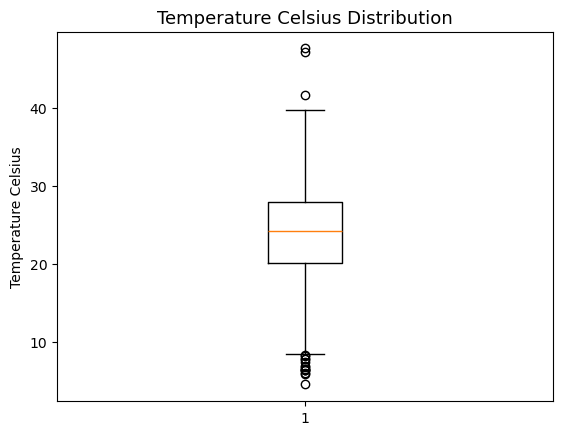

In [40]:
plt.boxplot(df['temperature_celsius'])
plt.ylabel('Temperature Celsius')
plt.title('Temperature Celsius Distribution', fontsize=13)
plt.show()

In [41]:
df[df['temperature_celsius'] > 40]

,region,transmission_type,patient_age,gender,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index,country_Argentina,country_Bolivia,country_Brazil,country_Canada,country_Chile,country_Mexico,country_Paraguay,country_Peru,country_USA,country_Uruguay,report_date_year,report_date_month,report_date_day,virus_strain_Andes,virus_strain_Dobrava,virus_strain_Puumala,virus_strain_Seoul,virus_strain_Sin Nombre,exposure_source_Agricultural Exposure,exposure_source_Cruise Exposure,exposure_source_Forest Exposure,exposure_source_Home Infestation,exposure_source_Rodent Exposure,exposure_source_Warehouse Exposure,"symptoms_Fatigue, Nausea, Chills","symptoms_Fever, Cough, Headache","symptoms_Fever, Muscle Pain, Fatigue","symptoms_Headache, Vomiting, Fever","symptoms_Shortness of Breath, Fever"
case_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
HV2026_00130,1,0,32,0,0,0,27.0,47.1,74.0,5,15,429,66,0,0,0,1,0,0,0,0,0,0,2025,5,8,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0
HV2026_01419,1,0,40,1,1,0,39.0,41.7,56.4,9,20,8608,158,0,1,0,0,0,0,0,0,0,0,2025,3,16,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0
HV2026_01634,2,0,56,0,0,0,33.0,47.6,37.1,2,11,4914,64,0,0,0,0,0,1,0,0,0,0,2026,3,8,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0


#### ****High temperature regions(Canada, Mexico, Bolivia) contains temperature more than 40°C****

In [42]:
df[df['temperature_celsius'] <= 10]

,region,transmission_type,patient_age,gender,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index,country_Argentina,country_Bolivia,country_Brazil,country_Canada,country_Chile,country_Mexico,country_Paraguay,country_Peru,country_USA,country_Uruguay,report_date_year,report_date_month,report_date_day,virus_strain_Andes,virus_strain_Dobrava,virus_strain_Puumala,virus_strain_Seoul,virus_strain_Sin Nombre,exposure_source_Agricultural Exposure,exposure_source_Cruise Exposure,exposure_source_Forest Exposure,exposure_source_Home Infestation,exposure_source_Rodent Exposure,exposure_source_Warehouse Exposure,"symptoms_Fatigue, Nausea, Chills","symptoms_Fever, Cough, Headache","symptoms_Fever, Muscle Pain, Fatigue","symptoms_Headache, Vomiting, Fever","symptoms_Shortness of Breath, Fever"
case_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
HV2026_00159,1,0,40,1,0,0,16.0,4.6,45.4,4,8,3381,189,0,0,0,0,0,1,0,0,0,0,2025,5,4,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0
HV2026_00377,1,1,28,1,1,0,44.0,7.8,89.9,3,20,9304,100,0,0,0,0,0,0,0,0,0,1,2025,8,18,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0
HV2026_00568,1,1,39,1,0,1,0.0,9.5,52.5,2,4,9167,163,0,0,0,0,0,0,0,0,0,1,2026,3,8,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0
HV2026_00618,1,1,13,0,1,1,0.0,6.9,70.6,10,2,1031,90,0,0,0,0,1,0,0,0,0,0,2025,10,28,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0
HV2026_00778,2,0,76,1,0,0,14.0,8.5,50.6,5,19,7244,83,0,0,1,0,0,0,0,0,0,0,2026,3,3,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0
HV2026_00895,1,0,15,1,1,0,36.0,9.5,55.8,9,20,1871,189,0,0,0,1,0,0,0,0,0,0,2026,4,3,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0
HV2026_00912,3,1,50,1,1,0,35.0,6.5,91.7,4,9,8271,176,0,0,0,0,0,0,0,1,0,0,2025,12,11,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0
HV2026_01003,1,0,15,0,0,0,17.0,7.8,54.0,6,1,4520,254,1,0,0,0,0,0,0,0,0,0,2026,4,8,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0
HV2026_01120,1,0,49,0,0,0,34.0,6.4,90.6,9,17,1173,59,0,0,0,1,0,0,0,0,0,0,2025,3,28,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1


#### ****Low temperature regions (Bolivia, Brazil, Canada, Chile, Mexico, Paraguay, Peru, USA, Uruguay) can have temperature below 10°C****

In [43]:
df['humidity_percent'].value_counts()

humidity_percent
76.8    10
91.2    10
83.2     9
56.3     9
84.3     9
36.5     9
61.4     8
73.0     8
54.5     8
38.5     8
87.6     8
74.5     8
39.3     8
82.9     8
46.1     8
35.3     7
92.8     7
59.7     7
53.9     7
60.7     7
64.0     7
87.0     7
72.5     7
79.3     7
50.6     7
48.6     7
75.8     7
38.1     7
48.2     7
94.2     6
38.0     6
64.3     6
93.2     6
45.9     6
71.5     6
82.7     6
85.3     6
69.7     6
39.0     6
75.1     6
83.8     6
37.3     6
67.9     6
39.9     6
81.8     6
55.1     6
86.0     6
35.7     6
57.8     6
56.0     6
58.1     6
40.1     6
71.6     6
49.4     6
61.0     6
39.4     6
51.1     6
57.3     6
73.5     6
62.5     6
45.4     6
76.7     6
51.4     6
49.5     6
90.7     6
69.6     6
44.8     6
56.6     6
43.1     6
76.3     6
88.2     6
39.1     6
66.1     6
87.7     6
46.2     6
83.4     6
49.8     6
42.2     6
59.1     5
89.6     5
58.8     5
38.7     5
60.1     5
92.5     5
75.6     5
51.9     5
40.3     5
84.0     5
36.3     5
64.4

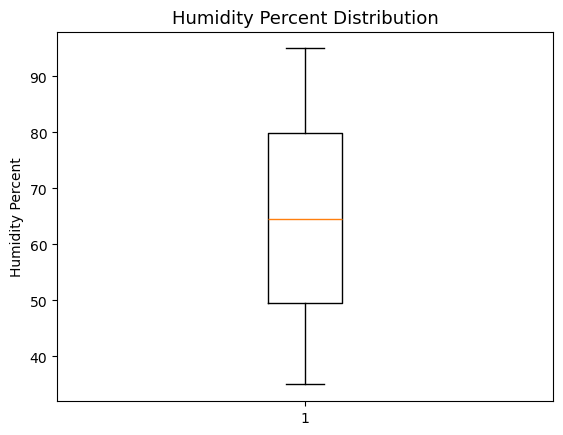

In [44]:
plt.boxplot(df['humidity_percent'])
plt.ylabel('Humidity Percent')
plt.title('Humidity Percent Distribution', fontsize=13)
plt.show()

In [45]:
df['rodent_presence_index'].value_counts()

rodent_presence_index
4     216
9     207
2     203
3     202
7     200
8     200
10    195
1     194
5     192
6     191
Name: count, dtype: int64

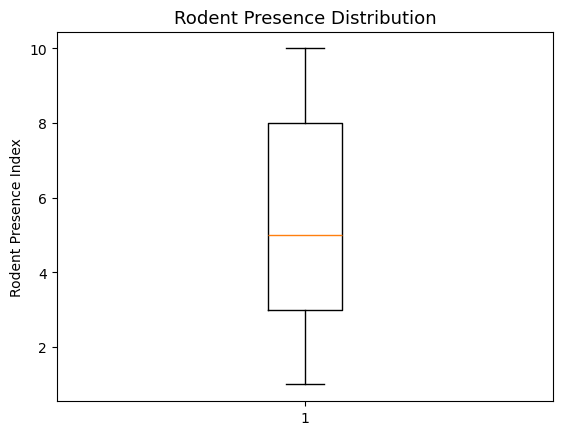

In [46]:
plt.boxplot(df['rodent_presence_index'])
plt.ylabel('Rodent Presence Index')
plt.title('Rodent Presence Distribution', fontsize=13)
plt.show()

In [47]:
df['quarantine_days'].value_counts()

quarantine_days
3     114
21    106
15    102
12    100
14     99
5      98
8      95
10     95
18     94
13     91
17     90
1      89
4      89
0      89
19     88
9      87
20     87
6      83
7      81
11     79
2      76
16     68
Name: count, dtype: int64

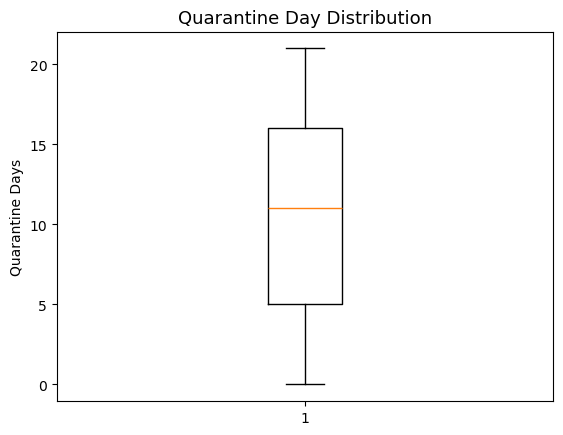

In [48]:
plt.boxplot(df['quarantine_days'])
plt.ylabel('Quarantine Days')
plt.title('Quarantine Day Distribution', fontsize=13)
plt.show()

In [49]:
df['population_density'].value_counts()

population_density
3318    3
9777    3
8860    3
9752    3
9347    3
8648    3
8641    3
5911    3
4365    2
59      2
695     2
7093    2
8149    2
7190    2
265     2
7158    2
9435    2
9299    2
3876    2
1686    2
9578    2
4614    2
6741    2
4353    2
8565    2
4763    2
8245    2
8483    2
5353    2
8608    2
9813    2
2048    2
5668    2
9669    2
3635    2
156     2
2797    2
2315    2
7483    2
7358    2
7300    2
1687    2
238     2
9247    2
325     2
4786    2
5329    2
852     2
7673    2
992     2
5921    2
3393    2
8106    2
5724    2
6000    2
1871    2
4310    2
9416    2
4070    2
2951    2
2400    2
384     2
7388    2
8027    2
1925    2
1071    2
1498    2
5938    2
6397    2
6561    2
4633    2
9903    2
216     2
8428    2
2695    2
4356    2
425     2
8823    2
3380    2
6687    2
8791    2
2671    2
3718    2
220     2
243     2
649     2
3110    2
4863    2
1386    2
5007    2
3305    2
1815    2
2209    2
5274    2
1790    2
1419    2
1031    2
2137    2
8

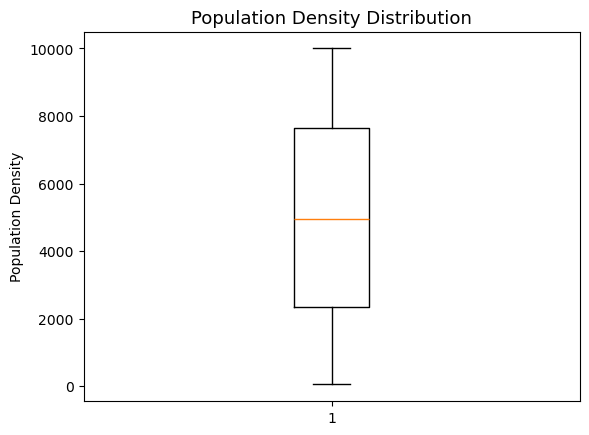

In [50]:
plt.boxplot(df['population_density'])
plt.ylabel('Population Density')
plt.title('Population Density Distribution', fontsize=13)
plt.show()

In [51]:
df['air_quality_index'].value_counts()

air_quality_index
59     15
236    15
262    15
130    14
234    13
252    13
257    13
269    13
228    12
239    12
122    12
87     12
163    12
288    12
184    12
187    12
32     12
273    12
40     12
124    12
208    12
74     11
140    11
223    11
71     11
194    11
23     11
255    11
210    11
241    11
31     11
294    11
38     11
259    11
33     11
21     11
113    10
66     10
193    10
216    10
165    10
93     10
119    10
227    10
127    10
242    10
265    10
189    10
110    10
254    10
112    10
152    10
90     10
43     10
296    10
180    10
191    10
270     9
69      9
237     9
135     9
247     9
161     9
67      9
136     9
219     9
106     9
63      9
204     9
225     9
233     9
70      9
176     9
102     9
41      9
290     9
51      9
89      9
215     9
131     9
166     9
175     9
213     9
121     9
169     8
263     8
134     8
83      8
114     8
133     8
168     8
57      8
88      8
37      8
154     8
111     8
172     8
190     8
26

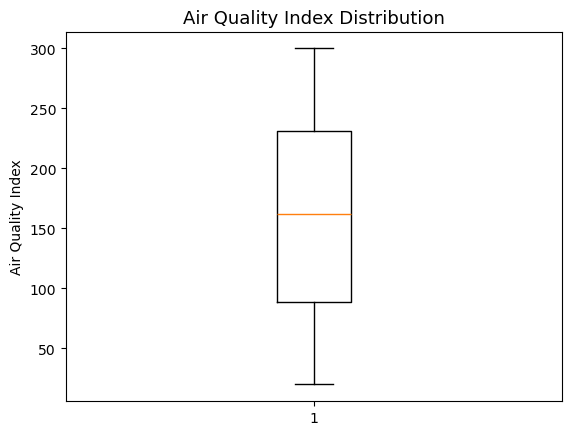

In [52]:
plt.boxplot(df['air_quality_index'])
plt.ylabel('Air Quality Index')
plt.title('Air Quality Index Distribution', fontsize=13)
plt.show()

# ****Case distribution by country and region — identify outbreak concentration zones****

In [53]:
country_columns = [c for c in df.columns if c.startswith("country_")]
df["country"] = (df[country_columns].idxmax(axis=1).str.replace("country_", ""))
country_region = (df.groupby(["country", "region"]).size().reset_index(name="Cases").sort_values("Cases", ascending=False))
country_region

,country,region,Cases
12,Canada,1,190
0,Argentina,1,181
32,USA,1,178
8,Brazil,1,176
36,Uruguay,1,175
4,Bolivia,1,175
24,Paraguay,1,174
20,Mexico,1,166
16,Chile,1,163
28,Peru,1,152


### ****Regions with frequency(number of rows) = 1 outbreaks concentration zones****

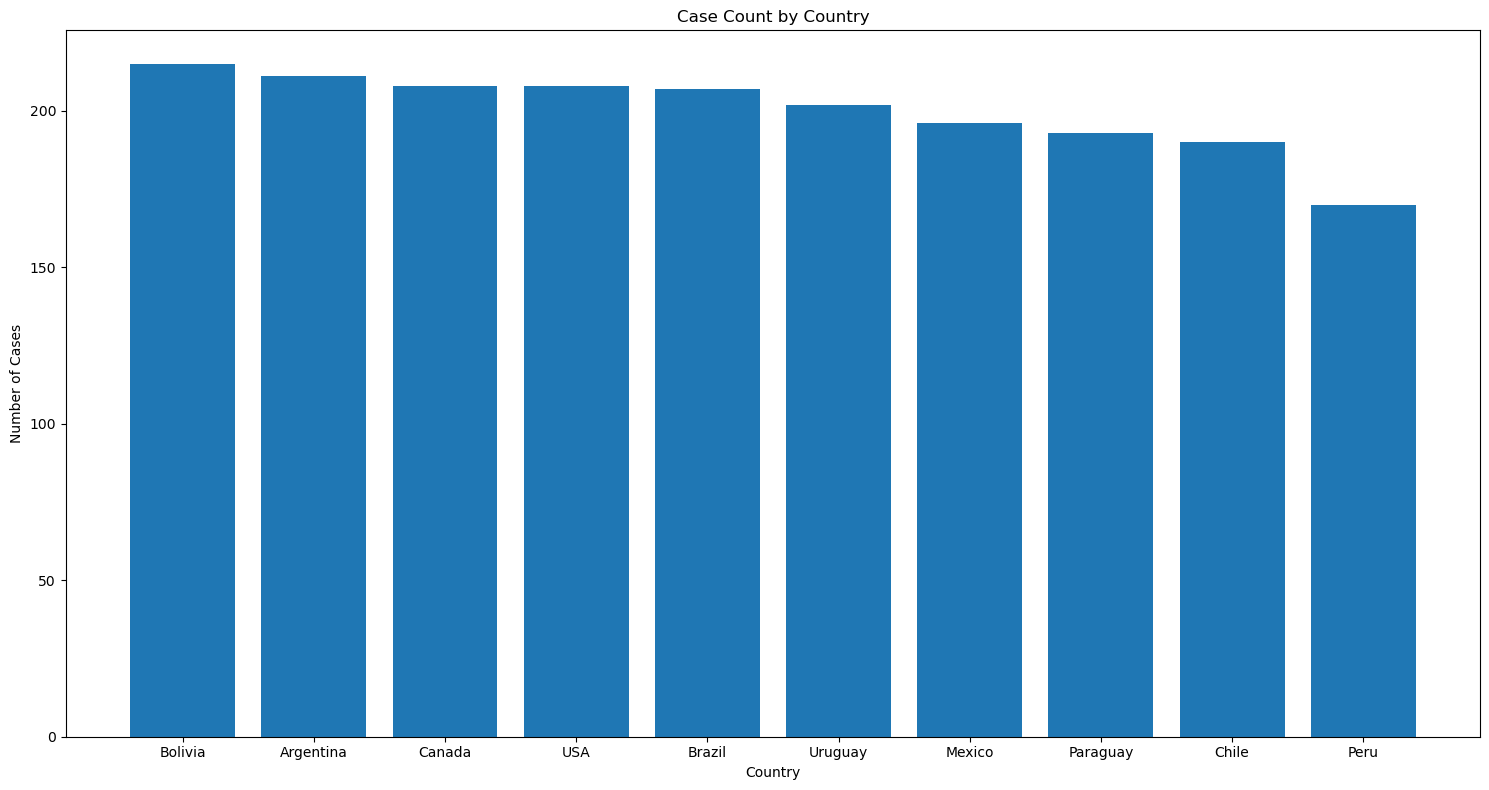

In [54]:
country_case_count = df['country'].value_counts()
plt.figure(figsize=(15, 8))
plt.bar(country_case_count.index, country_case_count.values)
plt.title("Case Count by Country")
plt.xlabel("Country")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()

In [55]:
df = df.drop(columns='country')

# ****Fatality rate by virus strain — determine which strain has the highest mortality****

In [56]:
virus_strain_columns = [c for c in df.columns if c.startswith('virus_strain_')]
df['virus_strain'] = df[virus_strain_columns].idxmax(axis=1).str.replace('virus_strain_', '')
df['fatality'] = le_fatality.inverse_transform(df['fatality'])
fatality_rate_virus_strain = df.groupby(['fatality', 'virus_strain']).size().reset_index(name='Cases').sort_values(by='fatality', ascending=False)
fatality_rate_virus_strain

,fatality,virus_strain,Cases
5,Yes,Andes,30
6,Yes,Dobrava,33
7,Yes,Puumala,25
8,Yes,Seoul,36
9,Yes,Sin Nombre,31
0,No,Andes,364
1,No,Dobrava,354
2,No,Puumala,349
3,No,Seoul,378
4,No,Sin Nombre,400


### ****Virus strain Sin Nombre has highest mortality****

In [57]:
le_fatality = LabelEncoder()
df['fatality'] = le_fatality.fit_transform(df['fatality'])

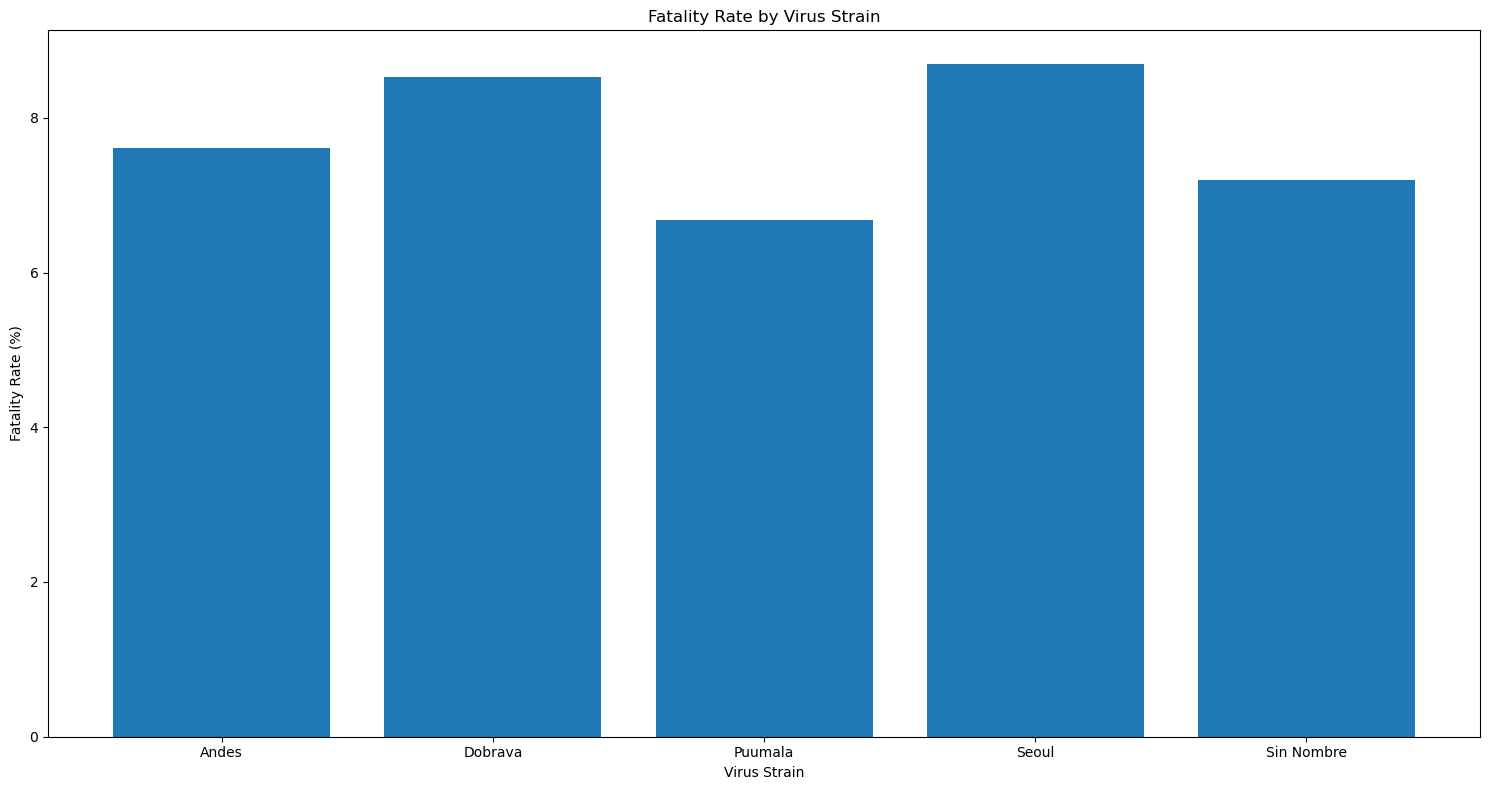

In [58]:
fatality_rate = (df.groupby('virus_strain')['fatality'].mean() * 100)
plt.figure(figsize=(15, 8))
plt.bar(fatality_rate.index, fatality_rate.values)
plt.title("Fatality Rate by Virus Strain")
plt.xlabel("Virus Strain")
plt.ylabel("Fatality Rate (%)")
plt.tight_layout()
plt.show()

In [59]:
df = df.drop(columns='virus_strain')

In [60]:
df['fatality'].value_counts()

fatality
0    1845
1     155
Name: count, dtype: int64

# ****Transmission type analysis — breakdown by type and exposure source****

In [61]:
exposure_source_columns = [c for c in df.columns if c.startswith('exposure_source_')]
df['exposure_source'] = df[exposure_source_columns].idxmax(axis=1).str.replace('exposure_source_', '')
df['transmission_type'] = le_transmission_type.inverse_transform(df['transmission_type'])
transmission_type_exposure_source = df.groupby(['transmission_type', 'exposure_source']).size().reset_index(name='Cases')
transmission_type_exposure_source

,transmission_type,exposure_source,Cases
0,Human-to-Human,Agricultural Exposure,157
1,Human-to-Human,Cruise Exposure,187
2,Human-to-Human,Forest Exposure,134
3,Human-to-Human,Home Infestation,171
4,Human-to-Human,Rodent Exposure,154
5,Human-to-Human,Warehouse Exposure,198
6,Rodent-to-Human,Agricultural Exposure,151
7,Rodent-to-Human,Cruise Exposure,167
8,Rodent-to-Human,Forest Exposure,191
9,Rodent-to-Human,Home Infestation,160


In [62]:
transmission_type_exposure_source_minimum = (transmission_type_exposure_source.loc[transmission_type_exposure_source.groupby('transmission_type')['Cases'].idxmin(),['transmission_type', 'exposure_source', 'Cases']])
transmission_type_exposure_source_minimum

,transmission_type,exposure_source,Cases
2,Human-to-Human,Forest Exposure,134
11,Rodent-to-Human,Warehouse Exposure,148


In [63]:
transmission_type_exposure_source_maximum = (transmission_type_exposure_source.loc[transmission_type_exposure_source.groupby('transmission_type')['Cases'].idxmax(),['transmission_type', 'exposure_source', 'Cases']])
transmission_type_exposure_source_maximum

,transmission_type,exposure_source,Cases
5,Human-to-Human,Warehouse Exposure,198
8,Rodent-to-Human,Forest Exposure,191


In [64]:
df = df.drop(columns=['transmission_type', 'exposure_source'])

# ****Environmental correlation — analyze relationship between temperature, humidity, rodent presence index and fatality outcome****

In [65]:
environmental_correlation_columns = ['temperature_celsius', 'humidity_percent', 'rodent_presence_index', 'fatality']
environmental_correlation = df[environmental_correlation_columns].corr()
environmental_correlation

,temperature_celsius,humidity_percent,rodent_presence_index,fatality
temperature_celsius,1.000000,0.017021,-0.018067,0.026984
humidity_percent,0.017021,1.000000,-0.007670,-0.008870
rodent_presence_index,-0.018067,-0.007670,1.000000,-0.070202
fatality,0.026984,-0.008870,-0.070202,1.000000


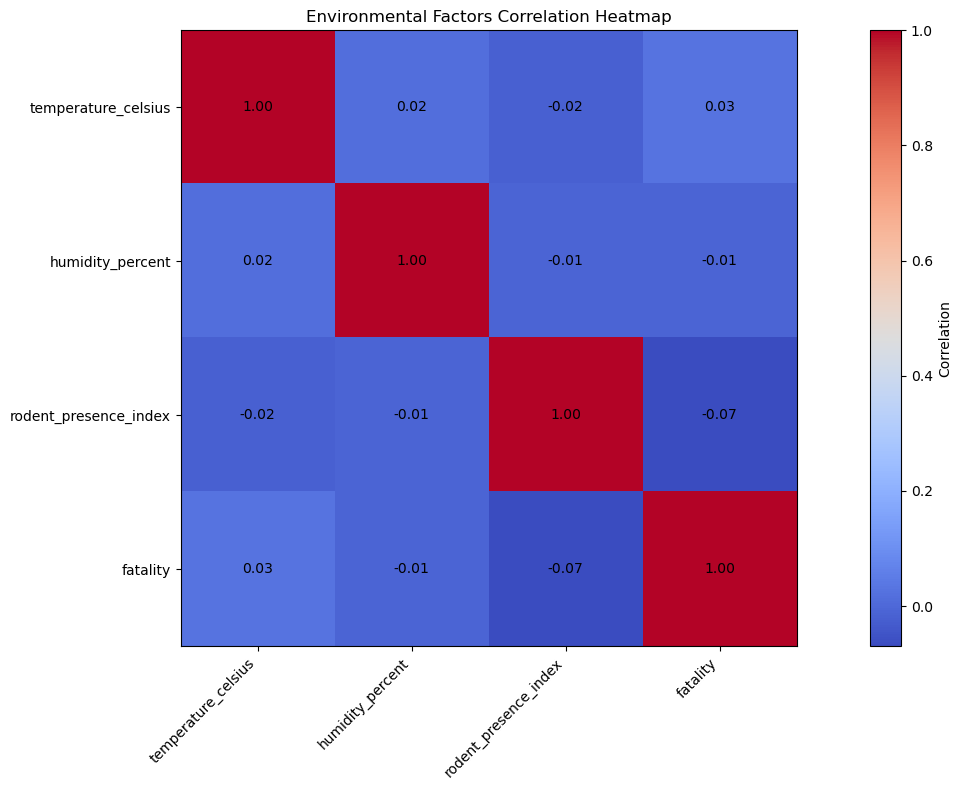

In [66]:
plt.figure(figsize=(15, 8))
plt.imshow(environmental_correlation, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')
plt.xticks(np.arange(len(environmental_correlation.columns)),environmental_correlation.columns,rotation=45,ha='right')
plt.yticks(np.arange(len(environmental_correlation.index)),environmental_correlation.index)
for i in range(len(environmental_correlation.index)):
    for j in range(len(environmental_correlation.columns)):
        plt.text(
            j,
            i,
            f"{environmental_correlation.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            color='black'
        )
plt.title("Environmental Factors Correlation Heatmap")
plt.tight_layout()
plt.show()

# ****Age group analysis — create age bins and identify the most affected demographic****

In [67]:
df['patient_age'].max()

78

In [68]:
bins = [0, 18, 40, 60, 80]
labels = ['0-17', '18-39', '40-59', '60_80']
df['patient_age_group'] = pd.cut(df['patient_age'], bins=bins, labels=labels, right=False)
df['patient_age_group'].value_counts().reset_index(name='Cases')

,patient_age_group,Cases
0,18-39,656
1,40-59,602
2,60_80,576
3,0-17,166


### ****Patient age group (18-39) are affected most compared to other age group****

In [69]:
df = df.drop('patient_age_group', axis=1)

# ****Recovery days comparison — hospitalized vs non-hospitalized patients****

In [70]:
df['hospitalization'] = le_hospitalization.inverse_transform(df['hospitalization'])
recovery_days_hospitalization = df.groupby(['hospitalization', 'recovery_days']).size().reset_index(name='Cases')
recovery_days_hospitalization

,hospitalization,recovery_days,Cases
0,No,0.0,79
1,No,7.0,19
2,No,8.0,29
3,No,9.0,22
4,No,10.0,24
5,No,11.0,17
6,No,12.0,33
7,No,13.0,21
8,No,14.0,23
9,No,15.0,21


In [71]:
recovery_days_hospitalization = df.groupby('hospitalization')['recovery_days'].agg( 
    Minimum = 'min',
    Maximum = 'max',
    Total = 'sum'
).reset_index()
recovery_days_hospitalization

,hospitalization,Minimum,Maximum,Total
0,No,0.0,45.0,24080.0
1,Yes,0.0,45.0,24431.0


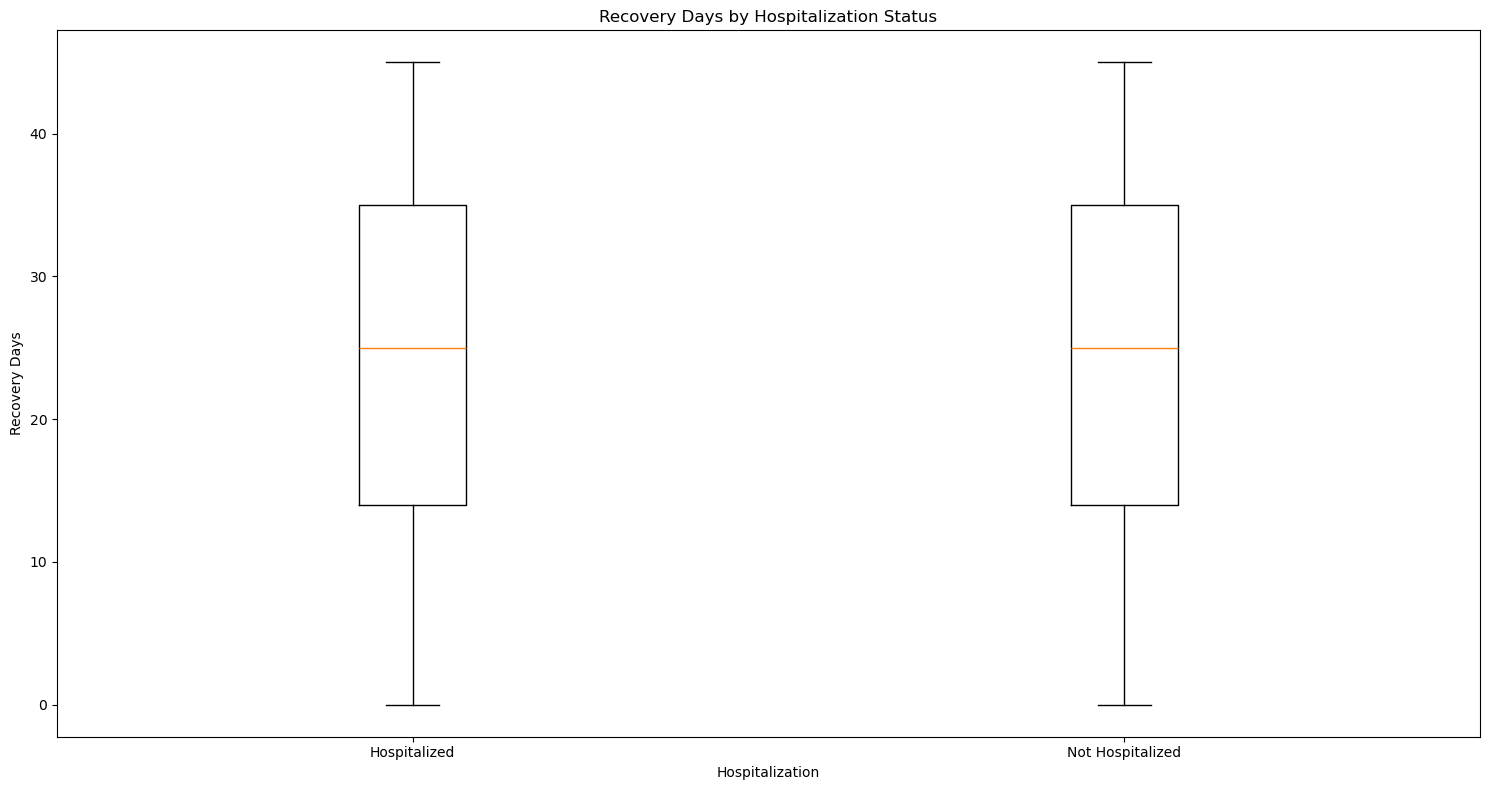

In [72]:
hospitalized = df[df['hospitalization'] == 'Yes']['recovery_days']
not_hospitalized = df[df['hospitalization'] == 'No']['recovery_days']
plt.figure(figsize=(15, 8))
plt.boxplot([hospitalized, not_hospitalized], tick_labels=['Hospitalized', 'Not Hospitalized'])
plt.title("Recovery Days by Hospitalization Status")
plt.xlabel("Hospitalization")
plt.ylabel("Recovery Days")
plt.tight_layout()
plt.show()

In [73]:
le_hospitalization = LabelEncoder()
df['hospitalization'] = le_hospitalization.fit_transform(df['hospitalization'])

# ****Feature importance chart — identify top predictors of fatality using correlation or a basic model**** 

In [74]:
correlation = df.corr()['fatality'].sort_values(ascending=False) * 100
correlation.drop('fatality')

country_Argentina                         4.046485
population_density                        3.287019
country_Chile                             2.726378
temperature_celsius                       2.698408
symptoms_Headache, Vomiting, Fever        2.569421
exposure_source_Forest Exposure           2.439426
country_Brazil                            1.815580
virus_strain_Seoul                        1.806949
symptoms_Fever, Muscle Pain, Fatigue      1.680993
virus_strain_Dobrava                      1.423636
country_Paraguay                          1.293512
report_date_year                          1.093865
exposure_source_Warehouse Exposure        1.080218
report_date_month                         0.857291
symptoms_Fever, Cough, Headache           0.787128
country_Peru                              0.553184
country_Canada                            0.539073
gender                                    0.416075
report_date_day                           0.282135
exposure_source_Home Infestatio

# ****Time series — monthly case count trend derived from report_date****

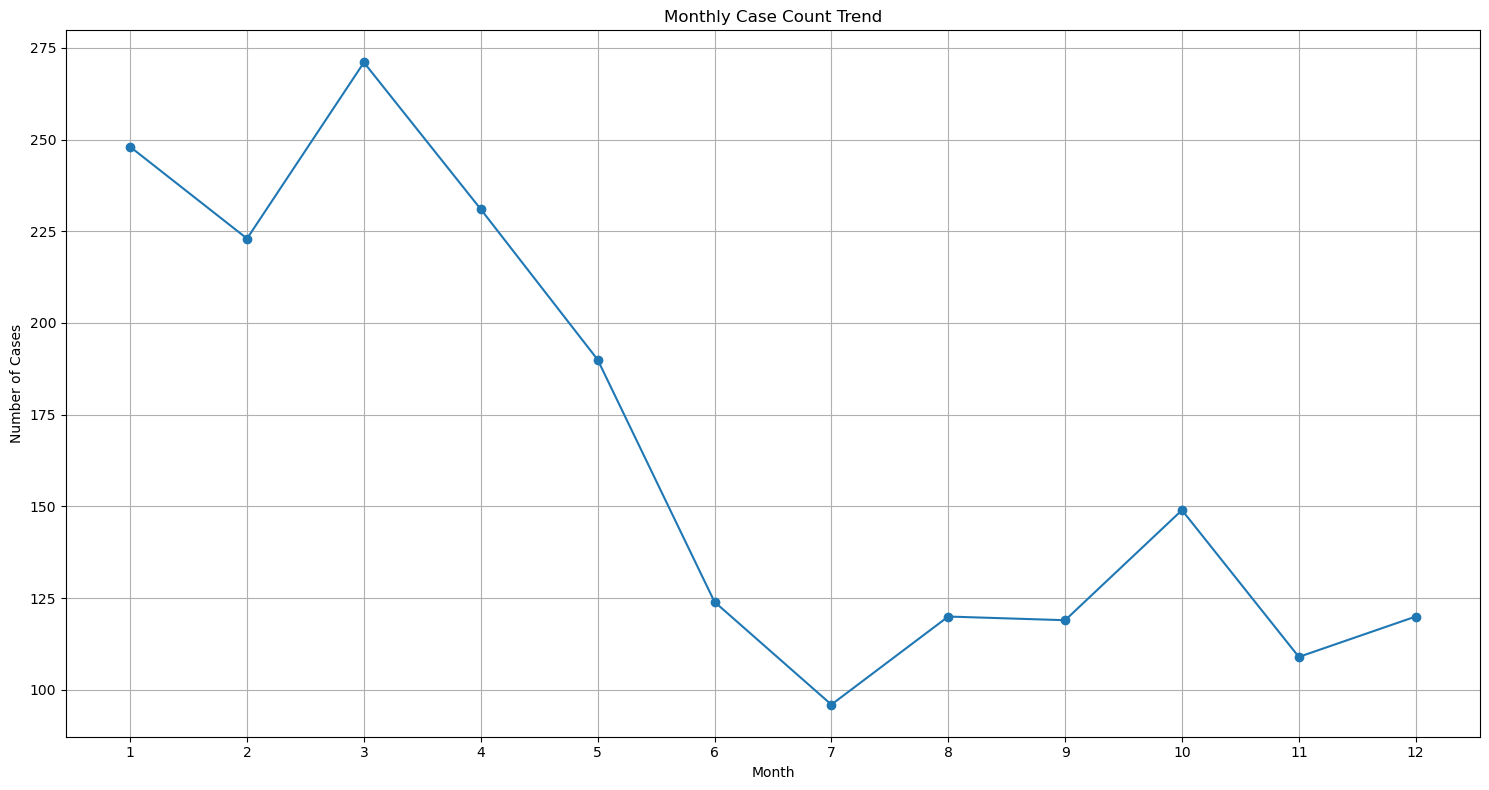

In [75]:
monthly_case_count = df['report_date_month'].value_counts().sort_index()
plt.figure(figsize=(15, 8))
plt.plot(monthly_case_count.index, monthly_case_count.values, marker='o')
plt.title("Monthly Case Count Trend")
plt.xlabel("Month")
plt.ylabel("Number of Cases")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

# ****Final epidemiology report section: 5 key findings with public health recommendations****

<div style="
    border: 3px solid;
    border-image: linear-gradient(to right, red, orange, yellow, green, blue, indigo, violet) 1;
    background-color:#f8fff8;
    border-radius:12px;
    padding:20px;
    box-shadow:0 4px 8px rgba(0,0,0,0.15);
    font-family:Arial, sans-serif;
">

<h2 style="color:#000000; margin-top:0;">
Final Epidemiology Report
</h2>


<h3 style="color:#000000">Key Findings:</h3>

<ol style="font-size:16px; line-height:1.8; color:#000000;">

<li>
Argentina has highest fatality correlation compared to other countries.
</li>

<li>
The Puumala virus strain has infected fewer patients compared to other virus strains.
</li>

<li>
Warehouse Exposure records the highest number of infected patients in Human-to-Human transmission and the lowest in Rodent-to-Human transmission while Forest Exposure records the highest number of infected patients in Rodent-to-Human transmission and the lowest in Human-to-Human transmission.
</li>

<li>
Hanta Virus has been spreading mainly in Adults(18+).
</li>

<li>
Spreading of Hanta Virus has been reported highest in March and lowest in July.
</li>

</ol>


<h3 style="color:#000000">Public Health Recommendations:</h3>

<ol style="font-size:16px; line-height:1.8; color:#000000;">

<li>
Regions of Frequency(Number of Columns) = 1 must be concentrated more in order to prevent spreading of Hanta Virus.
</li>

<li>
Large gatherings of people should be avoided since Hanta Virus is transmitted highly through human-to-human contact.
</li>

<li>
Adults(18+) should be more cautious since Hanta Virus mainly spread on them.
</li>

<li>
Government must improve Rodent Control Programs in forest areas in order to prevent Hanta Virus transmission.
</li>

<li>
People must wear mask and maintain social distance in infected areas. 
</li>

</div>